正式开始。

项目配置

In [ ]:
# ========== 配置单元 ===========

DATA_DIR = '../data'     # CSV 文件目录
FILES_INCLUDE = []       # 若留空，处理 DATA_DIR 下所有 CSV；否则填写文件名列表，例如 ['AAPL.csv']
MAX_DAYS = 252           # 每年对齐长度
PRED_RESOLUTION = 2000   # 预测曲线分辨率
N_RESTARTS = 50          # GPR 优化器随机重启次数
SAVE_PLOTS = True        # 是否把图保存到 ../results/<company>/
RESULTS_DIR = '../results'



In [2]:
# ========== 导入库 ===========
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (12, 5)

工具函数

In [3]:
# 读取与解析 CSV
def parse_close(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        return float(x.replace('$', '').replace(',', '').strip())
    return float(x)

# 读取与解析 CSV
def load_csv_as_df(path):

    df = pd.read_csv(path)

    # 提取 Date 列和 Close 列
    df = df.iloc[:, [0, 1]]
    df.columns = ['Date', 'Close']

    # 处理
    df['Date'] = pd.to_datetime(df['Date'])
    df['Close'] = df['Close'].apply(parse_close)
    df = df.dropna().sort_values('Date').reset_index(drop=True)
    return df

# 测试
#test_df = load_csv_as_df('../data/NVIDIA.csv')
test_df = load_csv_as_df('../data/MSFT.csv')
print(test_df)

           Date   Close
0    2015-12-21   54.83
1    2015-12-22   55.35
2    2015-12-23   55.82
3    2015-12-24   55.67
4    2015-12-28   55.95
...         ...     ...
2510 2025-12-15  474.82
2511 2025-12-16  476.39
2512 2025-12-17  476.12
2513 2025-12-18  483.98
2514 2025-12-19  485.92

[2515 rows x 2 columns]


In [ ]:
# 按年对齐 dataframe（每列为一年），加入 Quarter 列，填充每列末尾的 NaN 值

def build_equal_length_dataframe(df, max_days=MAX_DAYS):

    years = sorted(list({d.year for d in df['Date']}))
    print(years)

    results = {}
    
    for i, y in enumerate(years):
        prices = df.loc[df['Date'].dt.year == y, 'Close'].values
        mean = np.mean(prices)
        std = np.std(prices) if np.std(prices) > 0 else 1.0
        normalized = (prices - mean) / std
        prices = [(prices[i] - mean) / std for i in range(0, len(prices))]  # 获得标准化数据
        normalized = normalized - normalized[0]  # 从 0 开始

        arr = np.full(max_days, np.nan)
        L = min(len(normalized), max_days)
        arr[:L] = normalized[:L]

        results[y] = arr


    df_eq = pd.DataFrame(results)

    # 在数据中加入 Quarter 列（每季的样本数近似相等）
    qlist = []
    for q in range(4):
        qlist += [f'Q{q+1}'] * (max_days // 4)
    if len(qlist) < max_days:
        qlist += [f'Q4'] * (max_days - len(qlist))
    df_eq['Quarter'] = qlist[:max_days]

    # 用列均值填充末尾 NaN
    for col in df_eq.columns[:-1]:
        col_mean = np.nanmean(df_eq[col])
        df_eq[col] = df_eq[col].fillna(col_mean)

    df_eq.index.name = 'Day'
    return df_eq

# 测试
test_df_eq = build_equal_length_dataframe(test_df)
print(test_df_eq)

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
         2015      2016      2017      2018      2019      2020      2021  \
Day                                                                         
0    0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1    1.018825  0.065326 -0.040072  0.050620 -0.250153 -0.087146  0.005696   
2    1.939686 -0.195977 -0.040072  0.146798  0.054469 -0.069281 -0.147558   
3    1.645794 -0.687226  0.037210  0.283472  0.063211 -0.132461  0.016275   
4    2.194392 -0.645418  0.008587  0.294861  0.112972 -0.023094  0.052351   
..        ...       ...       ...       ...       ...       ...       ...   
247  1.792740  2.205395  3.265885  1.848895  3.783221  2.631800  3.384068   
248  1.792740  2.215847  3.310251  1.927356  3.869968  2.707181  3.351518   
249  1.792740  2.140069  3.311682  1.827381  3.889469  2.803477  3.370505   
250  1.792740  2.116552  3.285921  1.976710  3.797343  2.768183  3.299168   
251  1.79

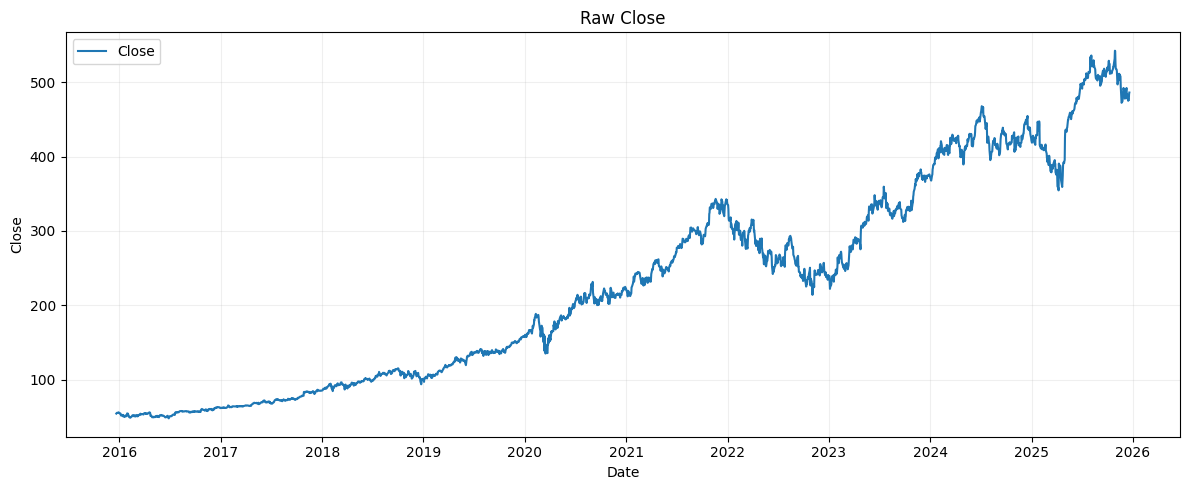

In [5]:
# 绘图：原始时间序列

def plot_raw(df, title=None, savepath=None):
    plt.figure()
    plt.plot(df['Date'], df['Close'], label='Close')
    plt.title(title or 'Raw Close')
    plt.xlabel('Date')
    plt.ylabel('Close')
    plt.grid(alpha=0.2)
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    plt.show()

# 测试
plot_raw(test_df)

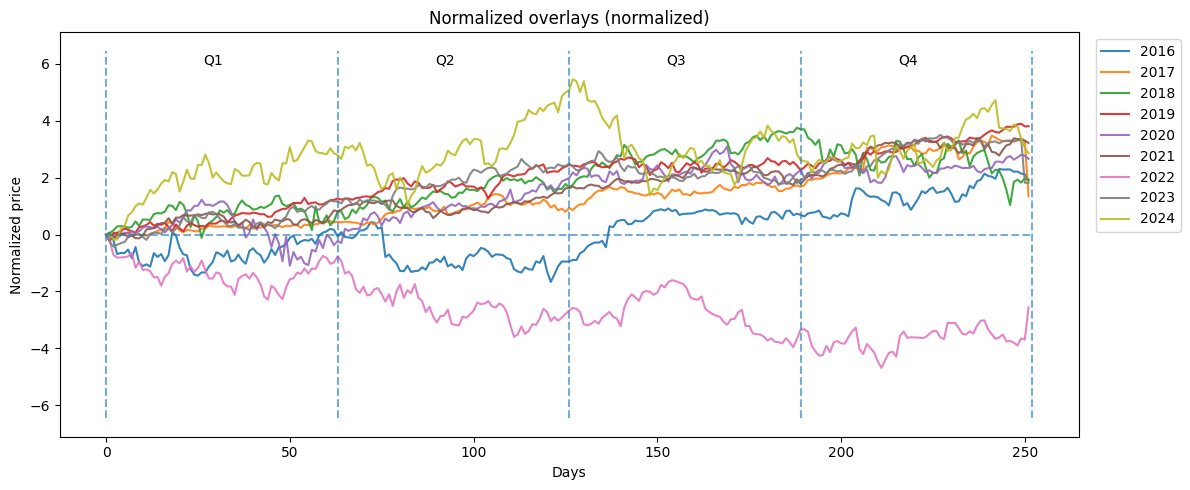

In [6]:
# 绘图：按年叠加的归一化曲线

def plot_normalized(df_eq, start_year: int, end_year: int, company_name=None, savepath=None):
    
    plt.figure()
    y_low, y_high = 0, 0

    for y in range(start_year, end_year + 1):
        series = df_eq[y].values
        x = np.arange(len(series))
        plt.plot(x, series, label=str(y), alpha=0.9)
        y_low = min(y_low, np.nanmin(series))
        y_high = max(y_high, np.nanmax(series))

    # 季度分界
    y_max = max(abs(y_low) + 1, abs(y_high) + 1)
    for i in range(5):
        plt.vlines(x=(len(series)/4)*i, ymin=-y_max, ymax=y_max, linestyles='--', alpha=0.6)
        if i < 4:
            plt.text((len(series)/4)*i + len(series)/8 - 5, y_max - 0.5, df_eq['Quarter'].iloc[i*(MAX_DAYS//4)])
    plt.hlines(0, 0, len(series), linestyles='--', alpha=0.6)

    plt.title(company_name or 'Normalized overlays (normalized)')
    plt.xlabel('Days')
    plt.ylabel('Normalized price')
    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
        
    plt.show()

# 测试
plot_normalized(test_df_eq, 2016, 2024)

In [ ]:
# 训练 GPR 并预测（训练集为指定年份列表，测试为一个年份）

def train_and_predict_gpr(df_eq, train_years, test_year,
                          n_restarts=N_RESTARTS, max_days=MAX_DAYS,
                          pred_resolution=PRED_RESOLUTION):
    
    # 构造训练集 X=[year, day], y=normalized price
    primary_year = min(train_years) # 通过减去 primary_year，用于将所有年份数值变换到较小的值（0~n）
    X_list = []
    y_list = []
    for y in train_years:
        vals = df_eq[y].values
        for day, v in enumerate(vals):
            if not np.isnan(v):
                X_list.append([y - primary_year, day])
                y_list.append(v)
    X_train = np.array(X_list, dtype=float)
    y_train = np.array(y_list, dtype=float)

    # 构造测试集
    test_vals = df_eq[test_year].values
    X_test = np.array([[test_year - primary_year, day] for day, v in enumerate(test_vals) if not np.isnan(v)], dtype=float)
    y_test = np.array([v for v in test_vals if not np.isnan(v)], dtype=float)

    # 搭建模型
    # kernel：趋势 + 周期 + 噪声
    rbf_kernel = RBF(length_scale=10.0, length_scale_bounds=(1e-2, 1e3))
    exp_kernel = ExpSineSquared(
        length_scale=50.0, periodicity=252,
        length_scale_bounds=(1e-2, 1e3), periodicity_bounds=(50, 400)
    )
    white_kernel = WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-6, 1e-1))
    kernel = 63.0 * rbf_kernel + 17.0 * exp_kernel + white_kernel

    gp = GaussianProcessRegressor(
        kernel=kernel, alpha=1e-6,
        normalize_y=True,
        n_restarts_optimizer=n_restarts
    )

    # 训练
    print(f"Training on years: {train_years}, test year: {test_year}, train samples: {len(X_train)}")
    gp.fit(X_train, y_train)
    print('Learned kernel:', gp.kernel_)

    # 预测
    x_mesh = np.linspace(0, max_days-1, pred_resolution)
    X_pred_mesh = np.array([[test_year - primary_year, x] for x in x_mesh], dtype=float)
    y_mean_mesh, y_cov_mesh = gp.predict(X_pred_mesh, return_cov=True)
    y_std_mesh = np.sqrt(np.diag(y_cov_mesh))

    # 用一组测试集的 X 预测，用于定量化评估
    y_pred_test = gp.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    r2 = r2_score(y_test, y_pred_test)

    print(f"Test RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")

    return {
        'model': gp,
        'x_mesh': x_mesh,
        'y_mean_mesh': y_mean_mesh,
        'y_std_mesh': y_std_mesh,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_test': y_pred_test,
        'metrics': {'rmse': rmse, 'mae': mae, 'r2': r2}
    }

# 测试
#prediction_dict = train_and_predict_gpr(test_df_eq, [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], 2025)

In [ ]:
# 绘图：预测曲线和真实曲线的对比

def plot_prediction(
        x_mesh, y_mean_mesh, y_std_mesh,
        X_test, y_test,
        max_days=MAX_DAYS,
        company_name=None, test_year=None,
        savepath=None
    ):

    # 均值、95% CI、真实点与预测点
    x_min, x_max = -10, max_days + 10
    y_lower = y_mean_mesh - 1.96 * y_std_mesh  # 使用 1.96 倍标准差作为 95% CI
    y_upper = y_mean_mesh + 1.96 * y_std_mesh
    y_max = max(abs(min(y_lower) - 1), abs(max(y_upper) + 1))
    test_days = [int(x[1]) for x in X_test]

    plt.figure()
    plt.title(f'{company_name} — GPR prediction for {test_year}')

    plt.plot(test_days, y_test, alpha=0.95, label=f'Observations {test_year}')
    plt.plot(x_mesh, y_mean_mesh, linestyle='--', label='GPR mean')
    plt.fill_between(x_mesh, y_lower, y_upper, alpha=0.25, label='95% CI')

    for i in range(5):
        plt.vlines(x=(max_days/4)*i, ymin=-y_max, ymax=y_max, linestyles='--', alpha=0.6)
    plt.hlines(y=0, xmin=x_min, xmax=x_max, color='black', linestyles='--', alpha=.6, zorder=-1)

    plt.xlabel('Days')
    plt.ylabel('Normalized price')
    plt.legend()
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

# 测试
# plot_prediction(
#     prediction_dict['x_mesh'], prediction_dict['y_mean_mesh'], prediction_dict['y_std_mesh'],
#     prediction_dict['X_test'], prediction_dict['y_test']
# )

Processing MSFT


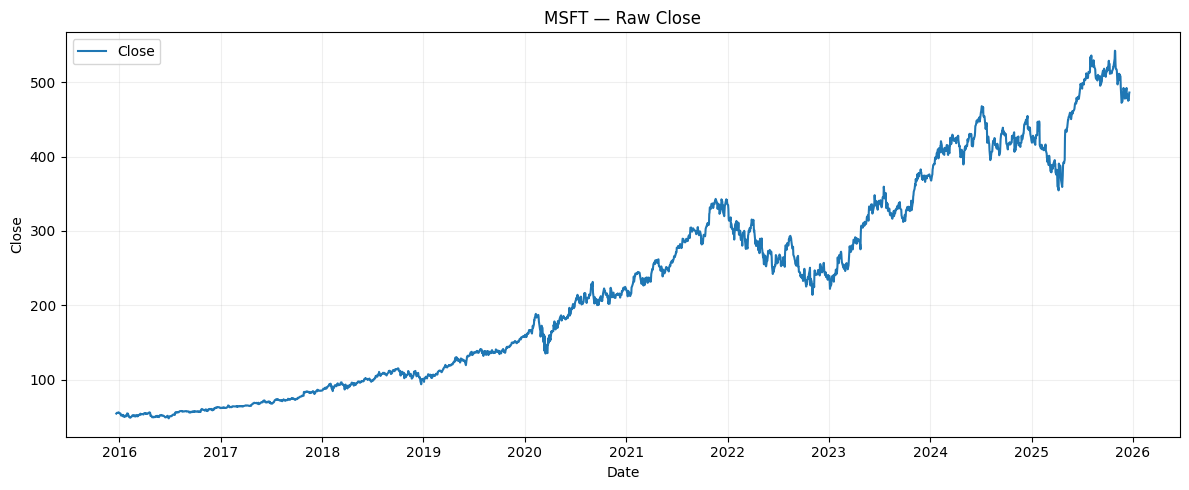

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


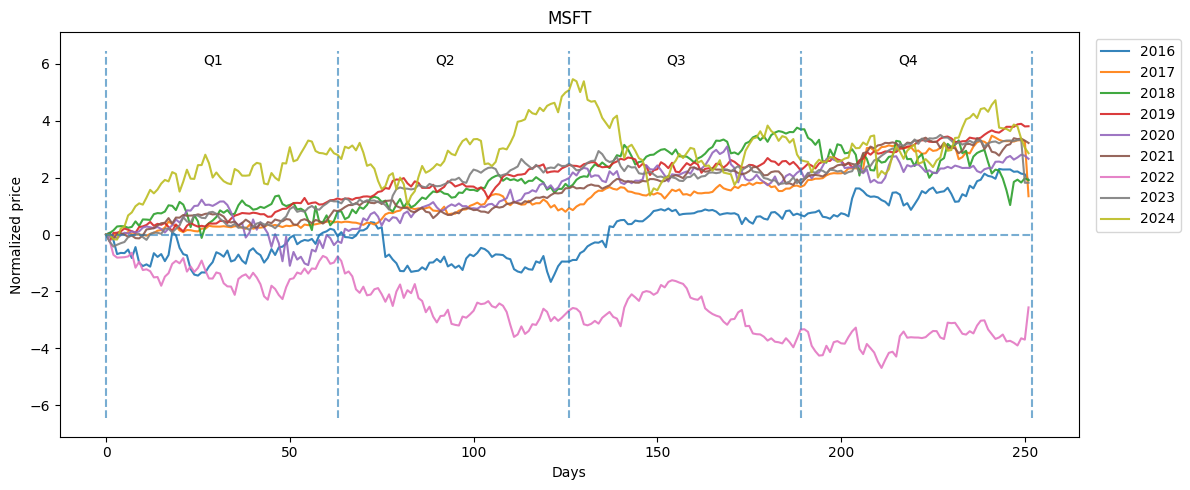

Training on years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], test year: 2025, train samples: 2268


d:\NewFiles\Anaconda\envs\database\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__periodicity is close to the specified upper bound 400. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\NewFiles\Anaconda\envs\database\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.06**2 * RBF(length_scale=0.912) + 0.402**2 * ExpSineSquared(length_scale=1.06, periodicity=400) + WhiteKernel(noise_level=1e-06)
Test RMSE: 1.2014, MAE: 0.9834, R2: -0.4968


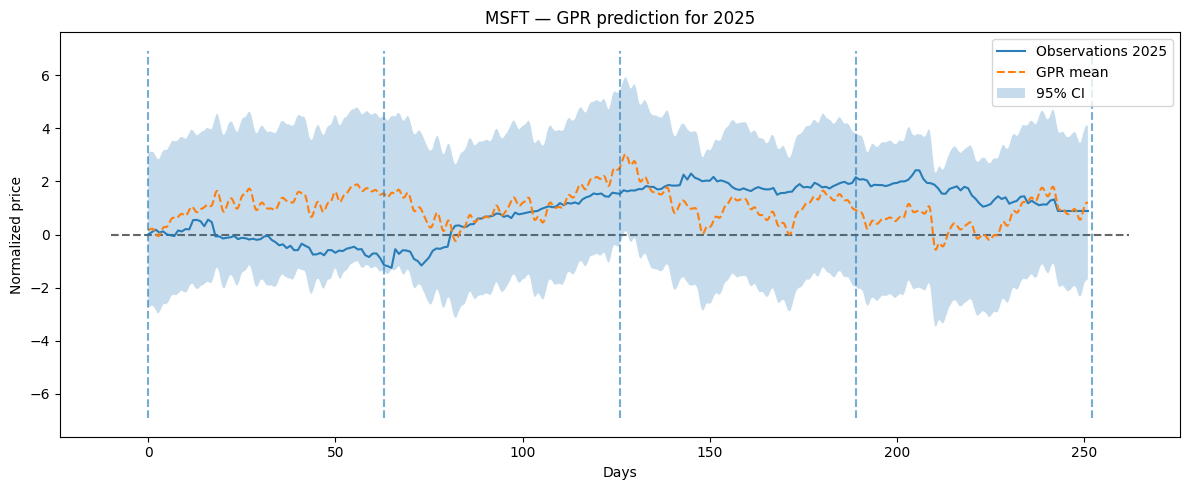

Metrics: {'rmse': np.float64(1.201389402526921), 'mae': 0.9834360352220108, 'r2': -0.49679340378191794}
Processing NTDOF


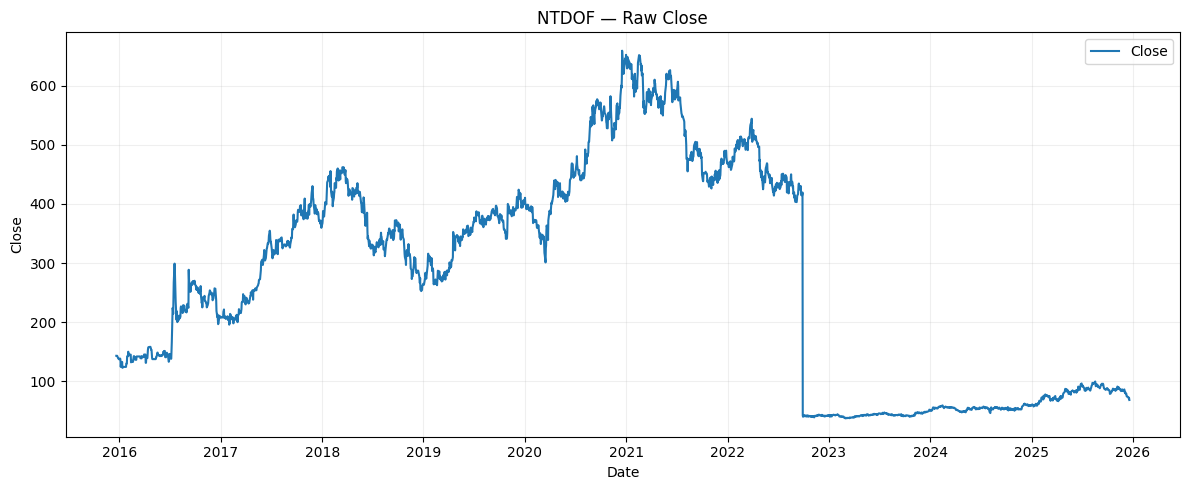

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


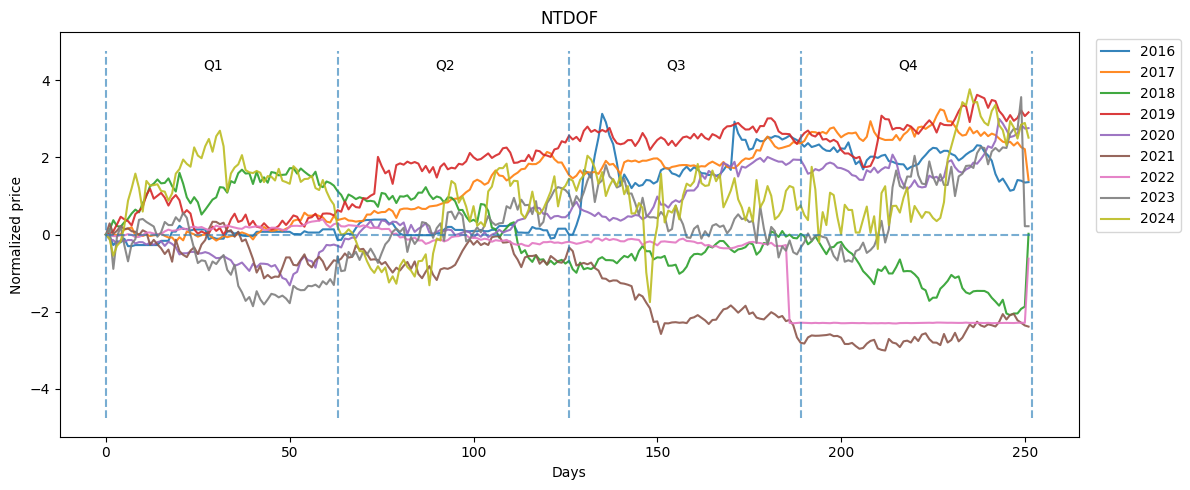

Training on years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], test year: 2025, train samples: 2268


d:\NewFiles\Anaconda\envs\database\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.15**2 * RBF(length_scale=1.02) + 0.00316**2 * ExpSineSquared(length_scale=0.0258, periodicity=248) + WhiteKernel(noise_level=0.00076)
Test RMSE: 2.0037, MAE: 1.7777, R2: -3.1636


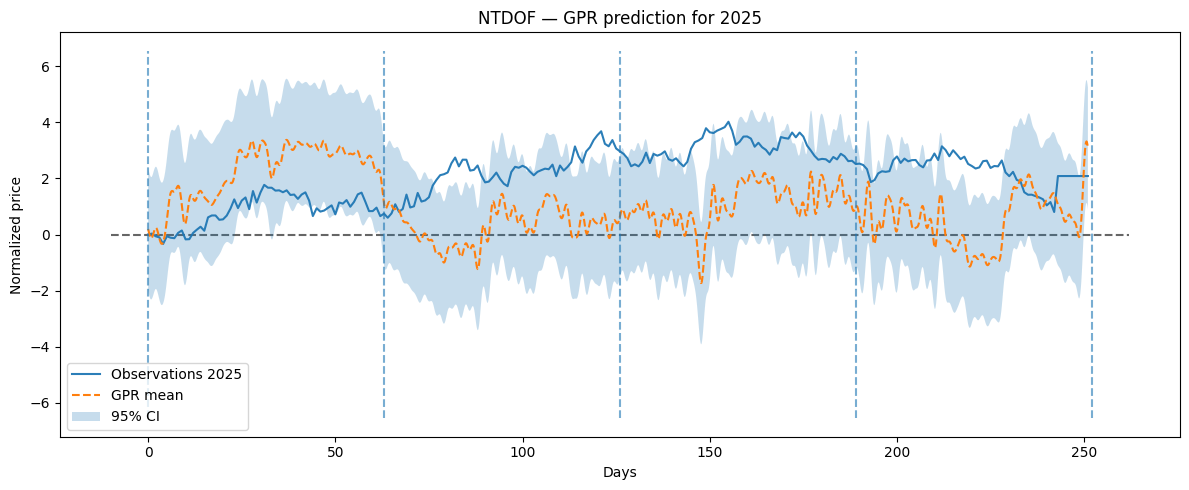

Metrics: {'rmse': np.float64(2.0037261654678495), 'mae': 1.7777135630754597, 'r2': -3.1636192330760666}
Processing NVDA


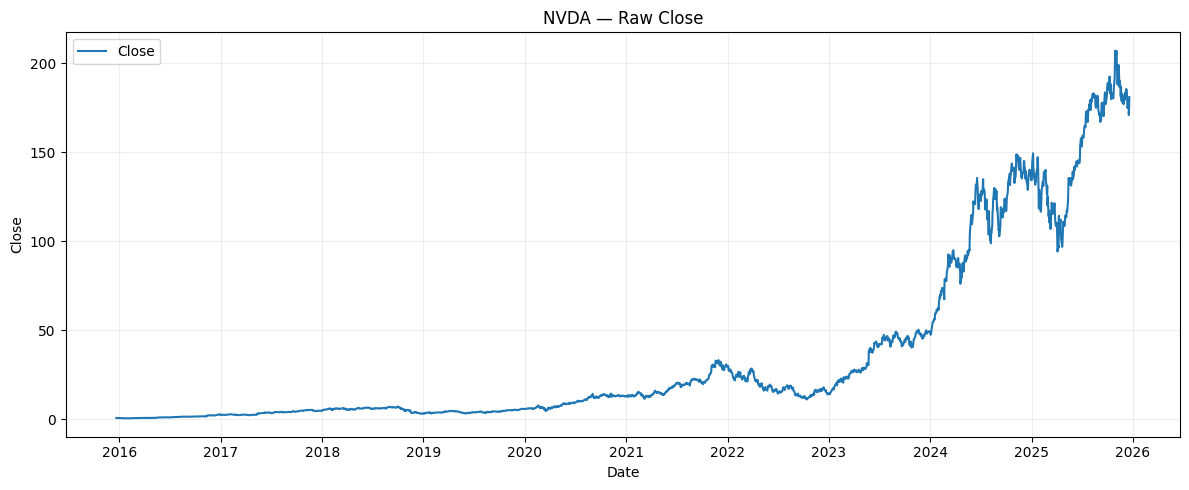

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


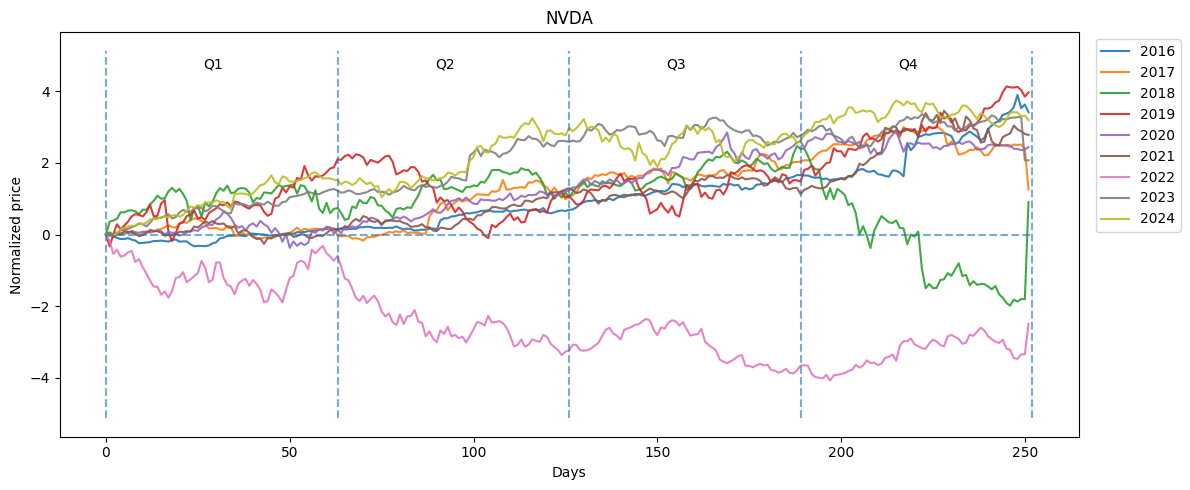

Training on years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], test year: 2025, train samples: 2268


d:\NewFiles\Anaconda\envs\database\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.11**2 * RBF(length_scale=0.892) + 0.00814**2 * ExpSineSquared(length_scale=549, periodicity=64.7) + WhiteKernel(noise_level=1e-06)
Test RMSE: 1.0366, MAE: 0.9134, R2: -0.1144


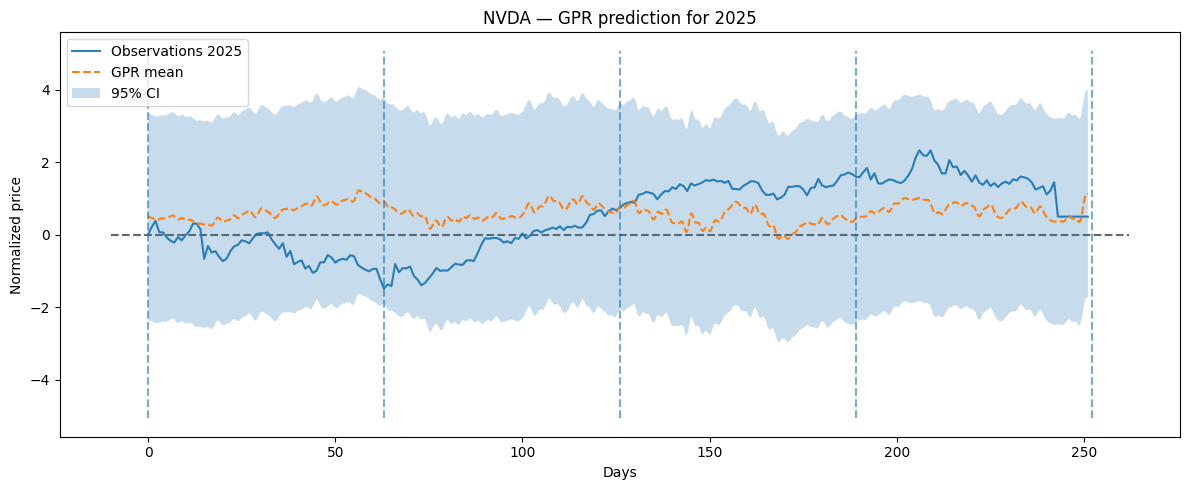

Metrics: {'rmse': np.float64(1.036644723301682), 'mae': 0.9134200975673847, 'r2': -0.1144334779917846}
Processing SEGA


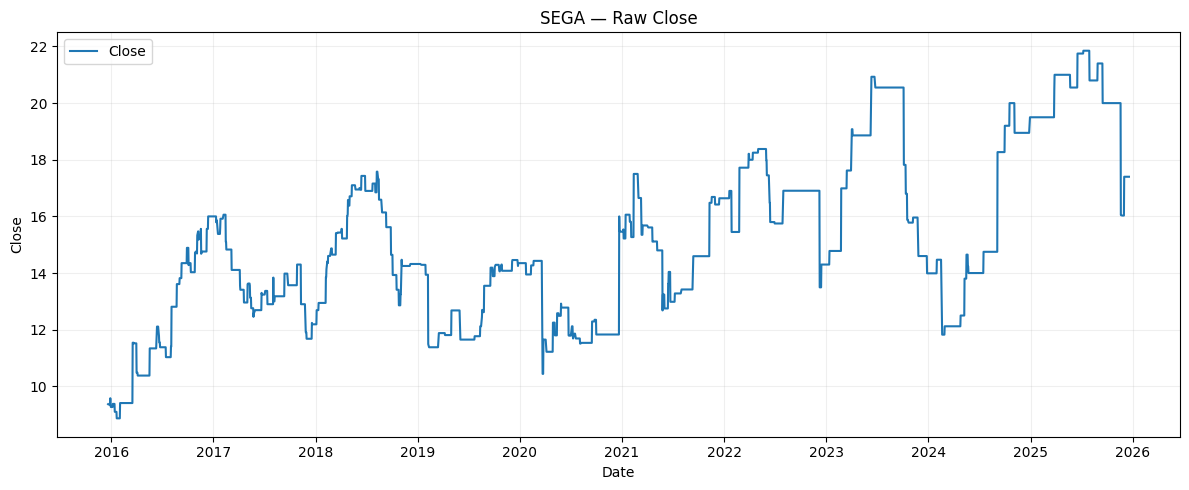

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


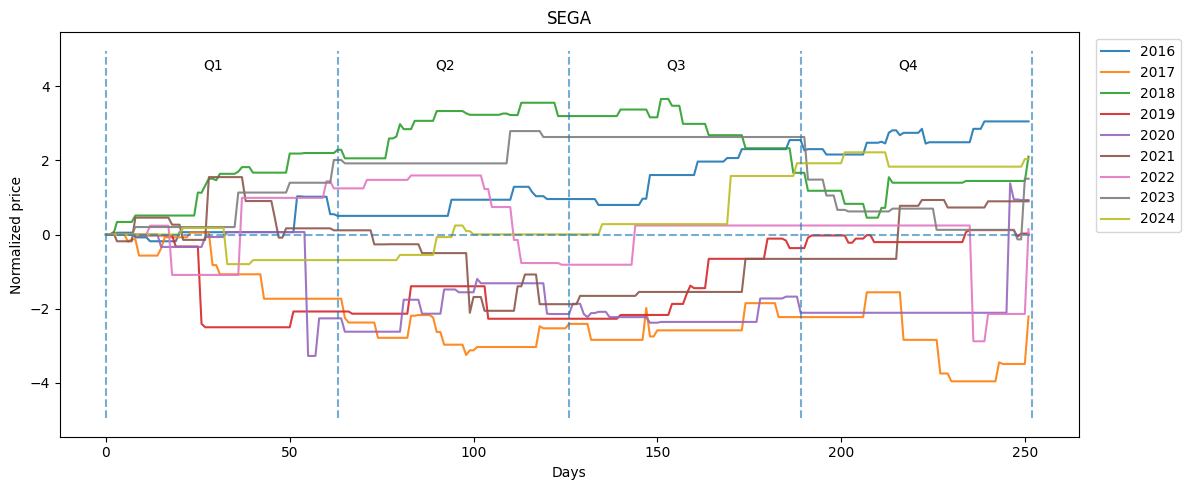

Training on years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], test year: 2025, train samples: 2268


d:\NewFiles\Anaconda\envs\database\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k2__periodicity is close to the specified upper bound 400. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
d:\NewFiles\Anaconda\envs\database\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Learned kernel: 1.51**2 * RBF(length_scale=1) + 0.319**2 * ExpSineSquared(length_scale=1.85, periodicity=400) + WhiteKernel(noise_level=1e-06)
Test RMSE: 1.9203, MAE: 1.5735, R2: -2.8240


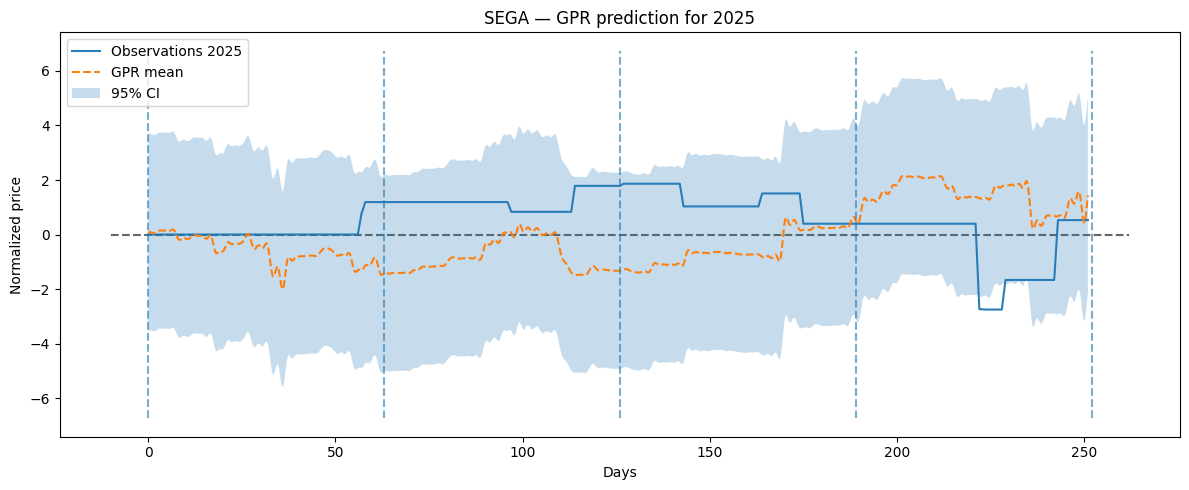

Metrics: {'rmse': np.float64(1.920268871541022), 'mae': 1.5735293683797444, 'r2': -2.8240041145282992}
Processing SONY


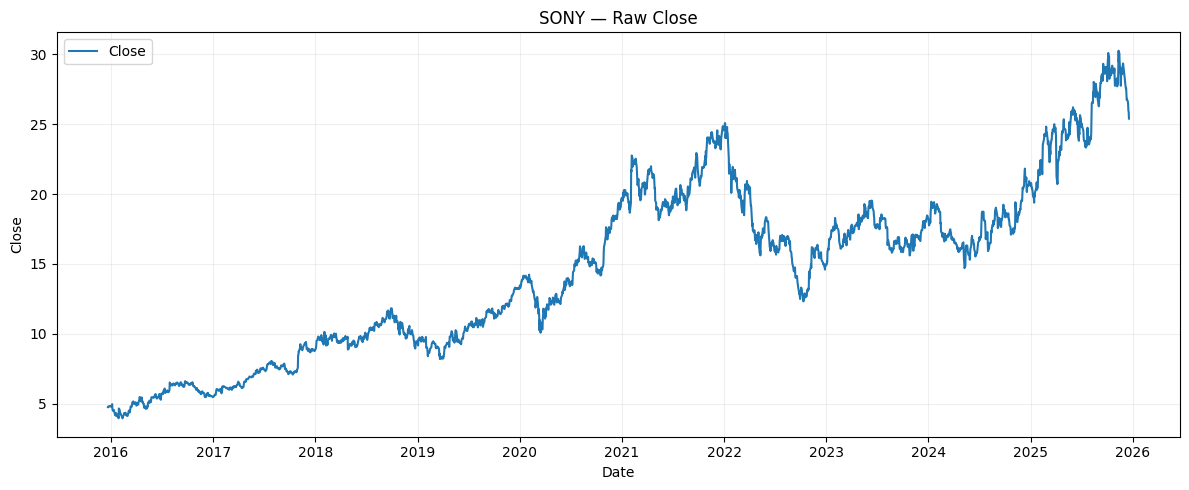

[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


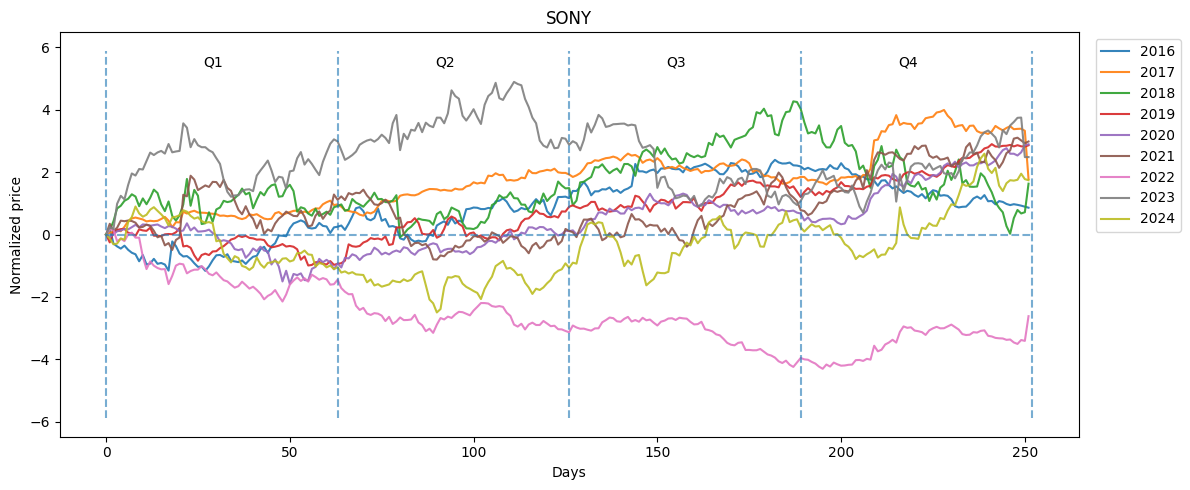

Training on years: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], test year: 2025, train samples: 2268
Learned kernel: 1.02**2 * RBF(length_scale=0.788) + 24.4**2 * ExpSineSquared(length_scale=5.07, periodicity=357) + WhiteKernel(noise_level=1.57e-06)
Test RMSE: 3.7875, MAE: 3.5293, R2: -13.8768


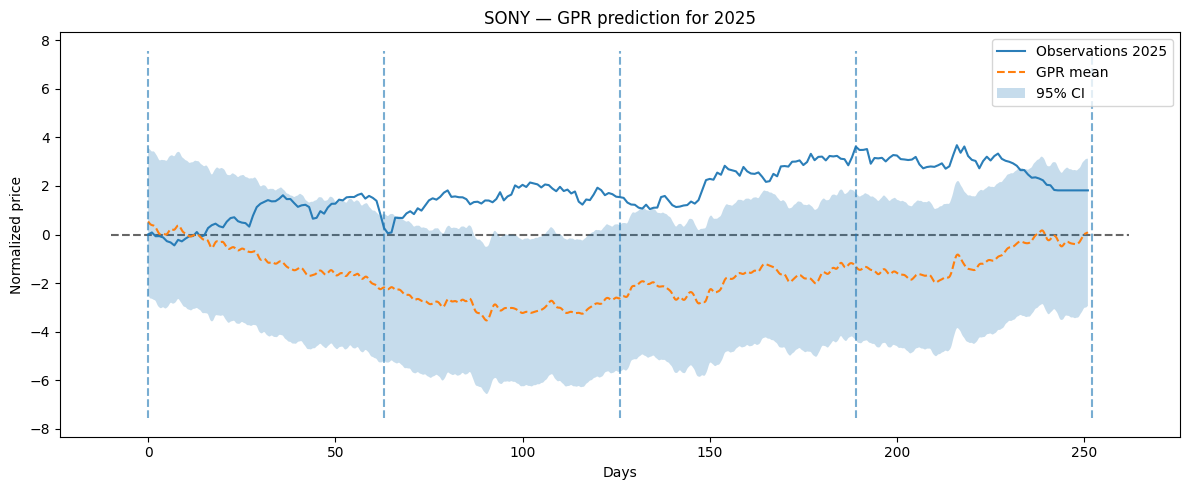

Metrics: {'rmse': np.float64(3.787546956645627), 'mae': 3.529302581326618, 'r2': -13.876827206158351}


In [ ]:
# 运行，遍历文件并按顺序处理（每个文件会输出图与指标）

def list_csv_files(data_dir=DATA_DIR, include_list=None):
    all_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))
    if include_list and len(include_list) > 0:
        all_files = [f for f in all_files if os.path.basename(f) in include_list]
    return all_files

# 默认训练为除最后一年的所有年份，测试为最后一年
train_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
test_year = 2025

# 读 csv
files = list_csv_files()
if len(FILES_INCLUDE) > 0:
    files = [f for f in files if os.path.basename(f) in FILES_INCLUDE]

if len(files) == 0:
    raise RuntimeError('No CSV files found in ' + DATA_DIR + ' (or check FILES_INCLUDE)')

# 对每个数据进行预测

results = {}

for path in files:
    company_name = os.path.splitext(os.path.basename(path))[0]
    
    # 创建结果目录（若需要保存）
    if SAVE_PLOTS:
        outdir = RESULTS_DIR + '/' + company_name
        os.makedirs(outdir, exist_ok=True)

    print('Processing', company_name)

    df = load_csv_as_df(path)

    # 原始数据图
    plot_raw(df, title=f'{company_name} — Raw Close', savepath=(outdir + '/' + company_name + '_raw.png') if SAVE_PLOTS else None)

    # 按年对齐，绘图
    df_eq = build_equal_length_dataframe(df, max_days=MAX_DAYS)
    plot_normalized(df_eq, start_year=train_years[0], end_year=train_years[-1], company_name=company_name, savepath=(outdir + '/' + company_name + '_normalized.png') if SAVE_PLOTS else None)

    # 按年对齐，绘图
    years = sorted([c for c in df_eq.columns if c != 'Quarter'])
    if len(years) < 2:
        print('Not enough years for training/testing. Skipping.')
        continue

    # 训练，绘图
    res = train_and_predict_gpr(
        df_eq, train_years, test_year,
        n_restarts=N_RESTARTS, max_days=MAX_DAYS,
        pred_resolution=PRED_RESOLUTION
    )
    plot_prediction(
        res['x_mesh'], res['y_mean_mesh'], res['y_std_mesh'],
        res['X_test'], res['y_test'],
        company_name=company_name, test_year=test_year,
        savepath=(outdir + '/' + company_name + '_prediction.png')
    )
    
    print('Metrics:', res['metrics'])

    results[company_name] = res
